# Word2Vec – Embeddingi słów
## Tutorial dla studentów

### Co to jest Word2Vec?

Word2Vec to technika, która **zamienia słowa w wektory liczb** (tzw. embeddingi).  
Kluczowa idea: **słowa o podobnym znaczeniu mają podobne wektory**.

Przykład: wektor słowa `król` – wektor `mężczyzna` + wektor `kobieta` ≈ wektor `królowa`

### Jak to działa?

Model uczy się na zasadzie: *"powiedz mi, z jakimi słowami sąsiadujesz, a powiem Ci kim jesteś"*.

Istnieją dwa warianty architektur:
- **CBOW** (Continuous Bag of Words) – przewiduj słowo na podstawie kontekstu
- **Skip-gram** – przewiduj kontekst na podstawie słowa (lepszy dla rzadkich słów)

W tym notebooku użyjemy tekstów polskiej literatury z serwisu **Wolne Lektury**.

---
## Krok 1 – Wczytanie tekstów

In [1]:
import os
import glob

# Ścieżka do folderu z lekturami
BOOKS_DIR = "../WOLNE_LEKTURY_SCRAPING/books"

# Zbieramy wszystkie pliki .txt rekurencyjnie
all_files = glob.glob(os.path.join(BOOKS_DIR, "**", "*.txt"), recursive=True)

print(f"Znaleziono {len(all_files)} plików tekstowych")
print("\nPrzykładowe pliki:")
for f in all_files[:5]:
    print(" ", f)

Znaleziono 7083 plików tekstowych

Przykładowe pliki:
  ../WOLNE_LEKTURY_SCRAPING/books/Dwudziestolecie międzywojenne/nuta-czlowiecza-opowiadanie.txt
  ../WOLNE_LEKTURY_SCRAPING/books/Dwudziestolecie międzywojenne/pawlikowska-jasnorzewska-bratki.txt
  ../WOLNE_LEKTURY_SCRAPING/books/Dwudziestolecie międzywojenne/pawlikowska-jasnorzewska-cien.txt
  ../WOLNE_LEKTURY_SCRAPING/books/Dwudziestolecie międzywojenne/nic-wiecej-z-pamietnika.txt
  ../WOLNE_LEKTURY_SCRAPING/books/Dwudziestolecie międzywojenne/pawlikowska-jasnorzewska-szpilki.txt


In [2]:
# Wczytujemy treść wszystkich plików
raw_texts = []
skipped = 0

for filepath in all_files:
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()
            if len(text) > 100:        # pomijamy bardzo krótkie pliki
                raw_texts.append(text)
    except Exception:
        skipped += 1

print(f"Wczytano: {len(raw_texts)} tekstów  |  pominięto: {skipped}")

# Całkowita liczba znaków
total_chars = sum(len(t) for t in raw_texts)
print(f"Łączna liczba znaków: {total_chars:,}  (~{total_chars // 1_000_000} MB tekstu)")

Wczytano: 7083 tekstów  |  pominięto: 0
Łączna liczba znaków: 305,269,528  (~305 MB tekstu)


---
## Krok 2 – Preprocessing (przygotowanie tekstu)

Zanim wytrenujemy model, musimy "oczyścić" tekst:
1. Zamienić na **małe litery** (żeby `Ptak` i `ptak` były tym samym słowem)
2. Usunąć **znaki interpunkcyjne** i cyfry
3. Podzielić tekst na **zdania** (każde zdanie = jeden kontekst nauki)
4. Podzielić zdania na **tokeny** (słowa)

In [3]:
import re

def preprocess(text: str) -> list[list[str]]:
    """
    Zamienia surowy tekst w listę zdań, gdzie każde zdanie
    to lista tokenów (słów).
    
    Zwraca: [["słowo1", "słowo2", ...], ["słowo3", ...], ...]
    """
    # Małe litery
    text = text.lower()

    # Usuwamy stopkę wolnelektury.pl (pojawia się na końcu każdego pliku)
    text = re.sub(r'-----.*', '', text, flags=re.DOTALL)

    # Dzielimy na zdania po kropce, wykrzykniku, pytajniku
    sentences_raw = re.split(r'[.!?]+', text)

    sentences = []
    for sent in sentences_raw:
        # Zostawiamy tylko litery (w tym polskie znaki) i spacje
        cleaned = re.sub(r'[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]', ' ', sent)
        # Tokenizacja: dzielimy po białych znakach
        tokens = cleaned.split()
        # Pomijamy zdania krótsze niż 3 słowa – za mało kontekstu
        if len(tokens) >= 3:
            sentences.append(tokens)

    return sentences


# Przykład działania preprocesingu
przyklad = "Pan Tadeusz wyszedł. Czy to możliwe? Tak, to prawda!"
print("Wejście:", przyklad)
print("Wyjście:", preprocess(przyklad))

Wejście: Pan Tadeusz wyszedł. Czy to możliwe? Tak, to prawda!
Wyjście: [['pan', 'tadeusz', 'wyszedł'], ['czy', 'to', 'możliwe'], ['tak', 'to', 'prawda']]


In [4]:
# Przetwarzamy WSZYSTKIE lektury
print("Przetwarzanie tekstów...")

all_sentences = []
for text in raw_texts:
    all_sentences.extend(preprocess(text))

print(f"Liczba zdań: {len(all_sentences):,}")
print(f"Liczba tokenów (szacunek): {sum(len(s) for s in all_sentences):,}")
print("\nPrzykładowe zdania po preprocessingu:")
for s in all_sentences[10:13]:
    print(" ", s)

Przetwarzanie tekstów...
Liczba zdań: 2,535,885
Liczba tokenów (szacunek): 38,810,190

Przykładowe zdania po preprocessingu:
  ['o', 'droga', 'panno', 'anno']
  ['w', 'moim', 'sercu']
  ['oprócz', 'śmiertelnej', 'strzały', 'jest', 'ich', 'tam', 'tyle', 'tyle', 'miałam', 'poduszkę', 'do', 'szpilek']


---
## Krok 3 – Trenowanie modelu Word2Vec

### Najważniejsze parametry:

| Parametr | Znaczenie | Typowe wartości |
|---|---|---|
| `vector_size` | Wymiarowość wektora słowa | 50–300 |
| `window` | Rozmiar okna kontekstu (ile słów w lewo/prawo) | 3–10 |
| `min_count` | Ignoruj słowa rzadziej niż N razy | 2–10 |
| `sg` | Architektura: `0` = CBOW, `1` = Skip-gram | 0 lub 1 |
| `epochs` | Liczba przebiegów po danych | 5–20 |
| `workers` | Liczba wątków CPU | = liczba rdzeni |


In [5]:
from gensim.models import Word2Vec
import time

start = time.time()

model = Word2Vec(
    sentences=all_sentences,  # nasze przetworzone zdania
    vector_size=100,          # każde słowo = wektor 100 liczb
    window=5,                 # okno kontekstu: 5 słów w lewo i 5 w prawo
    min_count=5,              # ignoruj słowa, które pojawiają się < 5 razy
    sg=1,                     # Skip-gram (lepszy dla nieczęstych słów)
    epochs=10,                # 10 przebiegów po całym zbiorze
    workers=4,                # 4 wątki
    seed=42                   # dla reprodukowalności wyników
)

elapsed = time.time() - start
print(f"Trenowanie zakończone w {elapsed:.1f} sekund")
print(f"Rozmiar słownika: {len(model.wv):,} unikalnych słów")

Trenowanie zakończone w 766.5 sekund
Rozmiar słownika: 257,917 unikalnych słów


---
## Krok 4 – Eksploracja modelu

### 4a. Wektor słowa

Każde słowo to teraz punkt w 100-wymiarowej przestrzeni.
Możemy go zobaczyć – ale jest trudny do interpretacji "gołym okiem".

In [6]:
import numpy as np

slowo = "miłość"
wektor = model.wv[slowo]

print(f"Wektor słowa '{slowo}':")
print(f"  Kształt: {wektor.shape}  (100 liczb)")
print(f"  Pierwsze 10 wartości: {wektor[:10].round(4)}")
print(f"  Norma (długość) wektora: {np.linalg.norm(wektor):.4f}")

Wektor słowa 'miłość':
  Kształt: (100,)  (100 liczb)
  Pierwsze 10 wartości: [-0.1717 -0.5575 -0.2887  0.2723  0.1369  0.3156  0.0035  0.4682 -0.3123
 -0.1556]
  Norma (długość) wektora: 3.2246


### 4b. Podobieństwo semantyczne

Podobieństwo mierzone jest **cosinusem kąta** między wektorami:
- `1.0` = identyczne kierunki (te same słowo)
- `0.0` = prostopadłe (brak związku)
- `-1.0` = przeciwne kierunki (antonimy)

In [7]:
# Podobieństwo między parami słów
pary = [
    ("król", "królowa"),
    ("miłość", "serce"),
    ("rzeka", "morze"),
    ("miecz", "bitwa"),
    ("chleb", "miłość"),
]

print(f"{'Słowo 1':15} {'Słowo 2':15} {'Podobieństwo':>12}")
print("-" * 44)

for w1, w2 in pary:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        print(f"{w1:15} {w2:15} {sim:>12.4f}")
    else:
        missing = [w for w in (w1, w2) if w not in model.wv]
        print(f"{w1:15} {w2:15}   brak w słowniku: {missing}")

Słowo 1         Słowo 2         Podobieństwo
--------------------------------------------
król            królowa               0.6919
miłość          serce                 0.5115
rzeka           morze                 0.5860
miecz           bitwa                 0.3154
chleb           miłość                0.2633


### 4c. Najbliżsi sąsiedzi (most_similar)

Dla danego słowa szukamy słów, których wektory są **najbliżej** w przestrzeni.

In [8]:
def pokaz_podobne(slowo, topn=10):
    if slowo not in model.wv:
        print(f"Słowo '{slowo}' nie ma w słowniku!")
        return
    podobne = model.wv.most_similar(slowo, topn=topn)
    print(f"\nNajbardziej podobne do '{slowo}':")
    for i, (word, score) in enumerate(podobne, 1):
        bar = "█" * int(score * 20)
        print(f"  {i:2}. {word:20} {score:.4f}  {bar}")

# pokaz_podobne("król")
# pokaz_podobne("miłość")
pokaz_podobne("gdańsk")


Najbardziej podobne do 'gdańsk':
   1. kraków               0.7385  ██████████████
   2. powiat               0.7054  ██████████████
   3. wiedeń               0.6855  █████████████
   4. szanghaj             0.6800  █████████████
   5. konstantynopol       0.6795  █████████████
   6. madryt               0.6790  █████████████
   7. kalisz               0.6772  █████████████
   8. tarnobrzeg           0.6736  █████████████
   9. bałkany              0.6729  █████████████
  10. płock                0.6720  █████████████


### 4d. Analogie słowne (działania na wektorach)

To "magia" Word2Vec: **arytmetyka semantyczna**.

```
król - mężczyzna + kobieta = ?
```

Model dodaje i odejmuje wektory, a potem szuka najbliższego słowa.

In [9]:
def analogia(positive, negative, topn=5):
    """
    Oblicza: positive[0] - negative[0] + positive[1] = ?
    
    Przykład: positive=["król", "kobieta"], negative=["mężczyzna"]
    Liczy: król - mężczyzna + kobieta = ?
    """
    # Sprawdź czy wszystkie słowa są w słowniku
    wszystkie = positive + negative
    brak = [w for w in wszystkie if w not in model.wv]
    if brak:
        print(f"Brak w słowniku: {brak}")
        return

    wyniki = model.wv.most_similar(positive=positive, negative=negative, topn=topn)
    
    plus  = " + ".join(positive)
    minus = " - ".join(negative)
    print(f"\n{plus} - {minus} = ?")
    for word, score in wyniki:
        print(f"  {word:20} ({score:.4f})")

# Klasyczne analogie
analogia(positive=["król", "kobieta"], negative=["mężczyzna"])
analogia(positive=["noc", "słońce"],   negative=["dzień"])
analogia(positive=["pies", "kociak"],  negative=["kot"])
analogia(positive=["polak", "niemiec"],  negative=["moskal"])


król + kobieta - mężczyzna = ?
  królowa              (0.8524)
  królewna             (0.7726)
  cesarzowa            (0.7623)
  księżniczka          (0.7578)
  księżna              (0.7201)

noc + słońce - dzień = ?
  niebo                (0.6910)
  ciemność             (0.6834)
  słonko               (0.6576)
  światło              (0.6474)
  toń                  (0.6430)

pies + kociak - kot = ?
  vatini               (0.7387)
  tiuzdejek            (0.7302)
  hycel                (0.7244)
  hipokryta            (0.7219)
  albinos              (0.7211)

polak + niemiec - moskal = ?
  komunista            (0.6546)
  socjalista           (0.6396)
  lenin                (0.6365)
  austrii              (0.6334)
  działacz             (0.6282)


### 4e. Znajdź "intruza"

Która ze słów nie pasuje do reszty?

In [10]:
def intruz(slowa):
    # Filtrujemy słowa których nie ma w słowniku
    dostepne = [w for w in slowa if w in model.wv]
    brak = [w for w in slowa if w not in model.wv]
    if brak:
        print(f"  Pominięto (brak w słowniku): {brak}")
    
    if len(dostepne) < 3:
        print("  Za mało słów w słowniku!")
        return

    wynik = model.wv.doesnt_match(dostepne)
    print(f"Spośród {dostepne}  →  INTRUZ: '{wynik}'")

intruz(["rzeka", "morze", "jezioro", "miecz"])
intruz(["radość", "miłość", "szczęście", "bitwa"])
intruz(["koń", "pies", "kot", "chleb"])

Spośród ['rzeka', 'morze', 'jezioro', 'miecz']  →  INTRUZ: 'miecz'
Spośród ['radość', 'miłość', 'szczęście', 'bitwa']  →  INTRUZ: 'bitwa'
Spośród ['koń', 'pies', 'kot', 'chleb']  →  INTRUZ: 'chleb'


---
## Krok 5 – Wizualizacja (t-SNE)

Wektory mają 100 wymiarów – nie da się ich narysować wprost.  
Używamy **t-SNE** (t-Distributed Stochastic Neighbor Embedding), żeby "spłaszczyć" je do 2D,  
zachowując (w przybliżeniu) lokalne relacje podobieństwa.

> t-SNE stara się umieścić blisko siebie te punkty, które w oryginalnej przestrzeni też były blisko.

In [11]:
import matplotlib.pyplot as plt
import matplotlib
from sklearn.manifold import TSNE

# Ustawiamy font obsługujący polskie znaki
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

def wizualizuj_tsne(grupy: dict, title="Word2Vec – wizualizacja t-SNE"):
    """
    grupy: słownik { 'nazwa_grupy': ['słowo1', 'słowo2', ...] }
    Rysuje każdą grupę innym kolorem.
    """
    # Zbieramy tylko słowa istniejące w modelu
    slowa = []
    etykiety_grup = []  # do kolorowania
    for nazwa_grupy, lista_slow in grupy.items():
        for slowo in lista_slow:
            if slowo in model.wv:
                slowa.append(slowo)
                etykiety_grup.append(nazwa_grupy)

    if len(slowa) < 5:
        print("Za mało słów w słowniku do wizualizacji!")
        return

    # Pobieramy wektory
    wektory = model.wv[slowa]   # kształt: (n_słów, 100)

    # Redukujemy do 2D przez t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=min(15, len(slowa) - 1),  # perplexity < n_słów
        random_state=42,
        max_iter=1000
    )
    wektory_2d = tsne.fit_transform(wektory)

    # Rysowanie
    fig, ax = plt.subplots(figsize=(12, 8))
    kolory = plt.cm.tab10.colors
    unikalne_grupy = list(grupy.keys())

    for i, (x, y) in enumerate(wektory_2d):
        kolor_idx = unikalne_grupy.index(etykiety_grup[i])
        kolor = kolory[kolor_idx % len(kolory)]
        ax.scatter(x, y, color=kolor, s=80, zorder=2)
        ax.annotate(
            slowa[i],
            (x, y),
            fontsize=11,
            ha='center',
            va='bottom',
            xytext=(0, 5),
            textcoords='offset points'
        )

    # Legenda
    from matplotlib.patches import Patch
    legend_patches = [
        Patch(color=kolory[i % len(kolory)], label=g)
        for i, g in enumerate(unikalne_grupy)
    ]
    ax.legend(handles=legend_patches, loc='best', fontsize=10)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("t-SNE wymiar 1")
    ax.set_ylabel("t-SNE wymiar 2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Funkcja wizualizacji załadowana.")

Funkcja wizualizacji załadowana.


In [12]:
# Definiujemy grupy tematyczne słów
grupy_tematyczne = {
    # "uczucia":     ["miłość", "radość", "smutek", "strach", "gniew", "nadzieja", "tęsknota"],
    # "natura":      ["rzeka", "las", "góra", "morze", "niebo", "ziemia", "wiatr", "słońce"],
    # "postacie":    ["król", "rycerz", "książę", "chłop", "szlachcic", "hetman"],
    # "religia":     ["bóg", "kościół", "modlitwa", "dusza", "grzech", "niebo"],
    # "walka":       ["miecz", "bitwa", "wojsko", "wróg", "obrona", "zwycięstwo"],
    "miasta":      ["Zosia", "Adam", "Telimena", "Andrzej", "Hrabia", "Tadeusz", "Rejent", "Podkomorzy"],
}

wizualizuj_tsne(grupy_tematyczne, "Wolne Lektury – semantyczne grupy słów (t-SNE)")

Za mało słów w słowniku do wizualizacji!


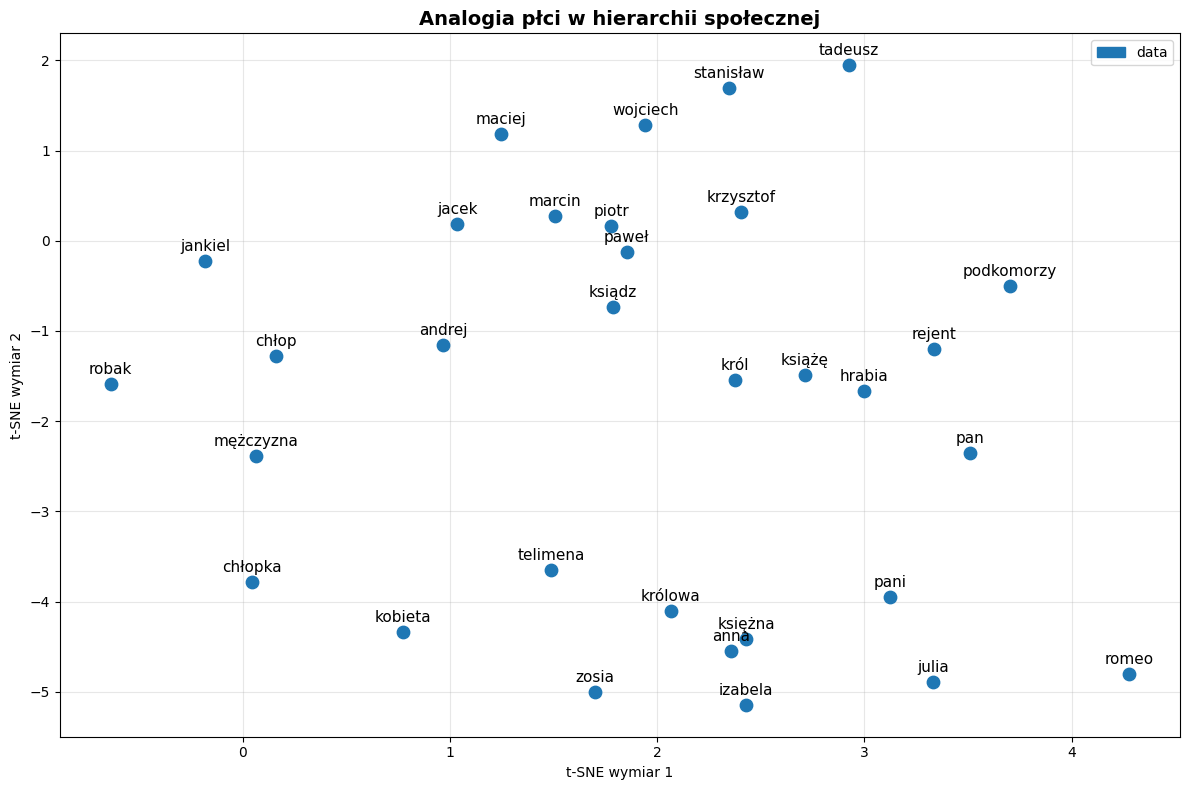

In [13]:
# Wizualizacja analogii: król - mężczyzna + kobieta = królowa?
grupy_analogii = {
    "data": ["romeo", "julia", "tadeusz", "zosia", "hrabia", "telimena", "andrej", "podkomorzy", "rejent", "król", "królowa", "książę", "księżna", "pan", "pani", "chłop", "chłopka", "mężczyzna", "kobieta", "robak", "stanisław", "izabela", "wojciech", "maciej", "krzysztof", "anna", "marcin", "piotr", "paweł", "jacek", "ksiądz", "jankiel"],
    # "postacie": ["król", "królowa", "książę", "księżna", "pan", "pani", "chłop", "chłopka"]
}

wizualizuj_tsne(grupy_analogii, "Analogia płci w hierarchii społecznej")

---
## Krok 6 – Zapis i wczytanie modelu

Model można zapisać i wczytać – nie trzeba trenować go za każdym razem.

In [14]:
# Zapis
model.save("wolne_lektury_w2v.model")
print("Model zapisany jako 'wolne_lektury_w2v.model'")

# Wczytanie (demonstracja)
model_loaded = Word2Vec.load("wolne_lektury_w2v.model")
print(f"Wczytano model ze słownikiem {len(model_loaded.wv):,} słów")

# Możemy też zapisać same wektory (KeyedVectors) – lżejszy format
model.wv.save("wolne_lektury_vectors.kv")
print("Wektory zapisane osobno jako 'wolne_lektury_vectors.kv'")

Model zapisany jako 'wolne_lektury_w2v.model'
Wczytano model ze słownikiem 257,917 słów
Wektory zapisane osobno jako 'wolne_lektury_vectors.kv'


---
## Krok 7 – Eksperymenty własne

Spróbuj sam! Zmień parametry modelu i obserwuj różnice.

In [15]:
# Porównanie CBOW vs Skip-gram
print("Trenuję CBOW...")
model_cbow = Word2Vec(
    sentences=all_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=0,          # <-- CBOW
    epochs=10,
    workers=4,
    seed=42
)
print("Gotowe!")

# Porównaj wyniki dla tego samego słowa
slowo_test = "miłość"
print(f"\nSkip-gram – podobne do '{slowo_test}':")
for w, s in model.wv.most_similar(slowo_test, topn=5):
    print(f"  {w:20} {s:.4f}")

print(f"\nCBOW – podobne do '{slowo_test}':")
for w, s in model_cbow.wv.most_similar(slowo_test, topn=5):
    print(f"  {w:20} {s:.4f}")

Trenuję CBOW...
Gotowe!

Skip-gram – podobne do 'miłość':
  namiętność           0.8313
  tkliwość             0.8205
  przyjaźń             0.8160
  czułość              0.7973
  najtkliwsza          0.7836

CBOW – podobne do 'miłość':
  przyjaźń             0.8312
  czułość              0.7955
  tkliwość             0.7938
  namiętność           0.7893
  nienawiść            0.7782


---
## Podsumowanie

| Temat | Co poznałeś |
|---|---|
| Preprocessing | Tokenizacja, czyszczenie tekstu |
| Trenowanie | Parametry Word2Vec: `vector_size`, `window`, `sg` |
| Podobieństwo | Cosinus – jak mierzyć bliskość słów |
| Analogie | Arytmetyka na wektorach (`most_similar`) |
| Wizualizacja | t-SNE – redukcja wymiarowości do 2D |
| Zapis | Jak zapisać i wczytać wytrenowany model |

### Dalsze kroki:
- **FastText** – ulepszone Word2Vec, radzi sobie ze słowami których nie widział
- **GloVe** – embeddingi trenowane na macierzy współwystępowań
- **BERT / GPT** – kontekstowe embeddingi (to samo słowo ma różne wektory w różnych zdaniach)